# 03 - Experiment 1: Factor IC Analysis (Raw vs Residual Returns)

Compare Rank IC and Pearson IC for all 6 factors across 11 industries,
using both raw returns (mret_w) and residual returns (r - beta * r_MSCI).

Key questions:
- Which factors best predict cross-sectional returns within each industry?
- Does using residual returns improve factor predictability?
- How stable are factor ICs over time?

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import (
    load_signal_data, load_benchmark, FACTOR_COLUMNS, FACTOR_NAMES,
    FACTOR_DIRECTIONS, INDUSTRIES, RETURN_COL_TESTING
)
from src.neutralization import neutralize_cross_section, impute_median
from src.residual_returns import compute_all_betas, compute_residual_returns
from src.factor_testing import (
    factor_summary_table, compute_monthly_ic, compute_ic_summary,
    compute_ic_correlation
)

DATA_DIR = '../data'
OUTPUT_DIR = '../output'

## 1. Data Preparation

In [2]:
df = load_signal_data(DATA_DIR)
benchmark = load_benchmark(DATA_DIR)
df_valid = df.dropna(subset=['industry']).copy()

# Impute missing factor values with industry-month median
for fac in FACTOR_COLUMNS:
    df_valid[fac] = impute_median(df_valid, fac)
    
print(f'After imputation, remaining NaN per factor:')
for fac in FACTOR_COLUMNS:
    n_na = df_valid[fac].isna().sum()
    print(f'  {FACTOR_NAMES[fac]}: {n_na}')

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03
Benchmark loaded: 289 months | 2001-05 to 2025-05


After imputation, remaining NaN per factor:
  Size: 0
  Value (P/B): 0
  Quality (ROE): 0
  Momentum: 2530
  Volatility: 2783
  Dividend Yield: 0


## 2. Country Neutralization

In [3]:
df_neutral = neutralize_cross_section(df_valid, FACTOR_COLUMNS)
neutral_factors = [f'{f}_neutral' for f in FACTOR_COLUMNS]
print(f'Neutralized factors: {neutral_factors}')

Neutralized factors: ['log_mktcap_neutral', 'pb_w_neutral', 'roe_w_neutral', 'mom_11m_w_neutral', 'ret_vol_w_neutral', 'div_yield_w_neutral']


## 3. Beta Estimation and Residual Returns

In [4]:
import time
t0 = time.time()
df_beta = compute_all_betas(df_neutral, benchmark)
t1 = time.time()
print(f'Beta estimation took {t1-t0:.1f}s')

print(f'\nBeta statistics:')
print(f'  Mean: {df_beta["beta"].mean():.3f}')
print(f'  Median: {df_beta["beta"].median():.3f}')
print(f'  Std: {df_beta["beta"].std():.3f}')
print(f'  NaN: {df_beta["beta"].isna().sum()}')

  Beta estimation: 500/950 stocks processed


  Beta estimation complete: 950 stocks
  Beta NaN fill: 15333 filled with industry-month median, 6171 remaining NaN
Beta estimation took 11.7s

Beta statistics:
  Mean: 0.959
  Median: 0.951
  Std: 0.354
  NaN: 6171


In [5]:
df_resid = compute_residual_returns(df_beta, benchmark)
print(f'Residual return (resid_ret) statistics:')
print(f'  Mean: {df_resid["resid_ret"].mean():.4f}')
print(f'  Std: {df_resid["resid_ret"].std():.4f}')
print(f'  NaN: {df_resid["resid_ret"].isna().sum()}')

Residual return (resid_ret) statistics:
  Mean: -0.0001
  Std: 0.0799
  NaN: 6555


## 4. IC Analysis: Raw Returns (mret_w)

In [6]:
# Using neutralized factors for IC computation
raw_ic_table = factor_summary_table(
    df_resid, neutral_factors, RETURN_COL_TESTING, method='rank'
)
raw_ic_table.index = raw_ic_table.index.set_levels(
    [FACTOR_NAMES.get(f.replace('_neutral', ''), f) for f in raw_ic_table.index.levels[0]],
    level=0
)

print('=== Rank IC: Raw Returns (mret_w) ===')
print(raw_ic_table[['avg_ic', 'ir', 't_stat', 'pct_positive']].round(4).to_string())

=== Rank IC: Raw Returns (mret_w) ===
                         avg_ic      ir  t_stat  pct_positive
factor         industry                                      
Size           BMATR     0.0314  0.1910  3.0499        0.5804
               CODIS     0.0344  0.2435  3.8877        0.6078
               COSTP     0.0139  0.0887  1.4159        0.5255
               ENEGY     0.0102  0.0491  0.7845        0.5216
               FINAN     0.0209  0.2030  3.2420        0.5922
               HLTHC     0.0563  0.2522  3.0580        0.5782
               INDUS     0.0346  0.2289  3.6560        0.5961
               RLEST     0.0339  0.1354  2.0040        0.5342
               TECNO     0.0593  0.3396  5.4231        0.6314
               TELCM     0.0312  0.1718  2.7438        0.5686
               UTILS     0.0271  0.1252  1.9987        0.5255
Value (P/B)    BMATR     0.0270  0.1490  2.3793        0.5686
               CODIS     0.0291  0.1526  2.4371        0.5843
               COSTP     0.0142 

## 5. IC Analysis: Residual Returns

In [7]:
resid_ic_table = factor_summary_table(
    df_resid, neutral_factors, 'resid_ret', method='rank'
)
resid_ic_table.index = resid_ic_table.index.set_levels(
    [FACTOR_NAMES.get(f.replace('_neutral', ''), f) for f in resid_ic_table.index.levels[0]],
    level=0
)

print('=== Rank IC: Residual Returns ===')
print(resid_ic_table[['avg_ic', 'ir', 't_stat', 'pct_positive']].round(4).to_string())

=== Rank IC: Residual Returns ===
                         avg_ic      ir  t_stat  pct_positive
factor         industry                                      
Size           BMATR     0.0332  0.1993  3.0296        0.5844
               CODIS     0.0376  0.2577  3.9169        0.5974
               COSTP     0.0072  0.0464  0.7053        0.5325
               ENEGY     0.0125  0.0604  0.9179        0.5152
               FINAN     0.0202  0.2118  3.2191        0.6017
               HLTHC     0.0610  0.2774  3.3628        0.6259
               INDUS     0.0378  0.2442  3.7121        0.6277
               RLEST     0.0304  0.1218  1.8027        0.5479
               TECNO     0.0558  0.3222  4.8964        0.6320
               TELCM     0.0226  0.1212  1.8423        0.5584
               UTILS     0.0278  0.1287  1.9567        0.5065
Value (P/B)    BMATR     0.0294  0.1646  2.5014        0.5844
               CODIS     0.0405  0.2241  3.4061        0.6190
               COSTP     0.0209  0.1

## 6. IC Comparison: Raw vs Residual

In [8]:
comparison = pd.DataFrame({
    'Raw |IC|': raw_ic_table['avg_ic'].abs(),
    'Resid |IC|': resid_ic_table['avg_ic'].abs(),
    'Raw IR': raw_ic_table['ir'],
    'Resid IR': resid_ic_table['ir'],
    'Raw t': raw_ic_table['t_stat'],
    'Resid t': resid_ic_table['t_stat'],
})

print('=== Comparison: Raw vs Residual ===')
print(comparison.round(4).to_string())

print(f'\nAverage |IC| - Raw: {comparison["Raw |IC|"].mean():.4f}')
print(f'Average |IC| - Residual: {comparison["Resid |IC|"].mean():.4f}')
print(f'Cases where residual IC is higher: {(comparison["Resid |IC|"] > comparison["Raw |IC|"]).sum()}/{len(comparison)}')

=== Comparison: Raw vs Residual ===
                         Raw |IC|  Resid |IC|  Raw IR  Resid IR   Raw t  Resid t
factor         industry                                                         
Size           BMATR       0.0314      0.0332  0.1910    0.1993  3.0499   3.0296
               CODIS       0.0344      0.0376  0.2435    0.2577  3.8877   3.9169
               COSTP       0.0139      0.0072  0.0887    0.0464  1.4159   0.7053
               ENEGY       0.0102      0.0125  0.0491    0.0604  0.7845   0.9179
               FINAN       0.0209      0.0202  0.2030    0.2118  3.2420   3.2191
               HLTHC       0.0563      0.0610  0.2522    0.2774  3.0580   3.3628
               INDUS       0.0346      0.0378  0.2289    0.2442  3.6560   3.7121
               RLEST       0.0339      0.0304  0.1354    0.1218  2.0040   1.8027
               TECNO       0.0593      0.0558  0.3396    0.3222  5.4231   4.8964
               TELCM       0.0312      0.0226  0.1718    0.1212  2.7438  

In [9]:
print('=== Average IC per Factor (across all industries) ===')
for ic_table, label in [(raw_ic_table, 'Raw Returns'), (resid_ic_table, 'Residual Returns')]:
    print(f'\n--- {label} ---')
    factor_avg = ic_table.groupby(level='factor').agg({
        'avg_ic': 'mean',
        'ir': 'mean',
        't_stat': 'mean',
        'pct_positive': 'mean',
        'n_months': 'mean',
    })
    factor_avg['abs_ic'] = factor_avg['avg_ic'].abs()
    factor_avg = factor_avg.sort_values('abs_ic', ascending=False)
    print(factor_avg[['avg_ic', 'abs_ic', 'ir', 't_stat', 'pct_positive']].round(4).to_string())
    print()

=== Average IC per Factor (across all industries) ===

--- Raw Returns ---
                avg_ic  abs_ic      ir  t_stat  pct_positive
factor                                                      
Size            0.0321  0.0321  0.1844  2.8421        0.5692
Value (P/B)     0.0283  0.0283  0.1447  2.2616        0.5589
Dividend Yield -0.0171  0.0171 -0.0846 -1.2714        0.4665
Momentum        0.0168  0.0168  0.0810  1.2357        0.5376
Volatility     -0.0133  0.0133 -0.0573 -0.8446        0.4792
Quality (ROE)   0.0119  0.0119  0.0670  1.0712        0.5263


--- Residual Returns ---
                avg_ic  abs_ic      ir  t_stat  pct_positive
factor                                                      
Size            0.0315  0.0315  0.1810  2.6692        0.5754
Value (P/B)     0.0280  0.0280  0.1493  2.2377        0.5636
Dividend Yield -0.0181  0.0181 -0.0905 -1.3163        0.4581
Momentum        0.0160  0.0160  0.0785  1.1694        0.5282
Volatility     -0.0149  0.0149 -0.0722 -1.06

## 7. Heatmap: Average IC by Factor and Industry

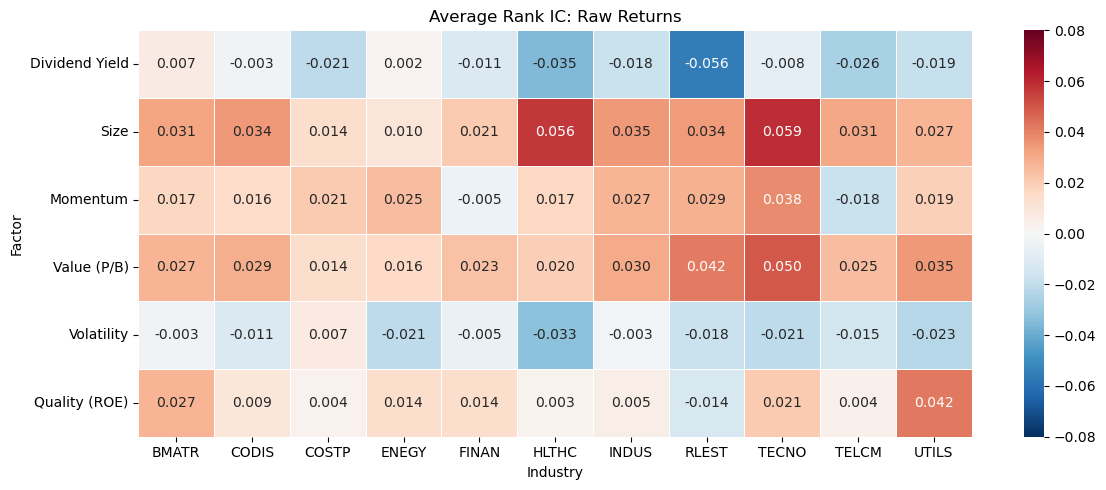

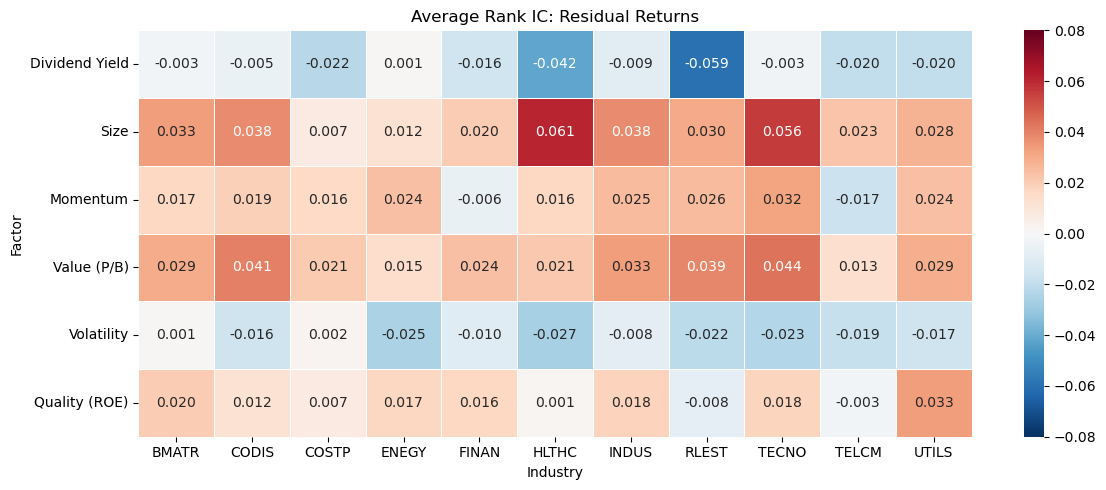

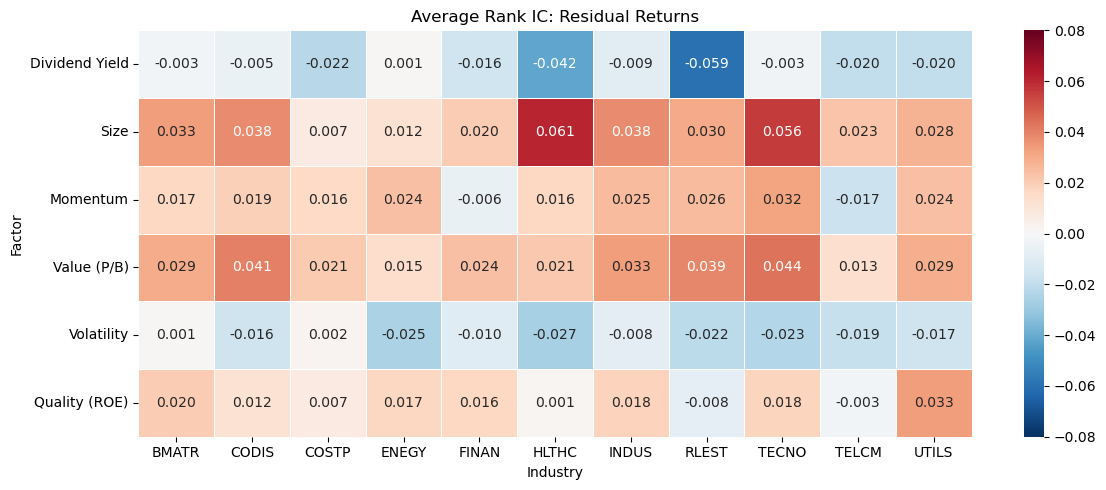

In [10]:
def make_ic_heatmap(ic_table, title, save_path=None):
    pivot = ic_table['avg_ic'].unstack(level=1)
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                ax=ax, linewidths=0.5, vmin=-0.08, vmax=0.08)
    ax.set_title(title)
    ax.set_ylabel('Factor')
    ax.set_xlabel('Industry')
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, format='pdf')
    plt.show()
    return fig

make_ic_heatmap(raw_ic_table, 'Average Rank IC: Raw Returns',
                f'{OUTPUT_DIR}/figures/ic_heatmap_raw.pdf')
make_ic_heatmap(resid_ic_table, 'Average Rank IC: Residual Returns',
                f'{OUTPUT_DIR}/figures/ic_heatmap_resid.pdf')

## 8. Best Factor per Industry

In [11]:
print('=== Best factor per industry (by |avg IC|) ===')
for ic_table, label in [(raw_ic_table, 'Raw'), (resid_ic_table, 'Residual')]:
    print(f'\n--- {label} Returns ---')
    for ind in INDUSTRIES:
        ind_data = ic_table.xs(ind, level='industry')
        best_factor = ind_data['avg_ic'].abs().idxmax()
        best_ic = ind_data.loc[best_factor, 'avg_ic']
        best_t = ind_data.loc[best_factor, 't_stat']
        print(f'  {ind}: {best_factor} (IC={best_ic:.4f}, t={best_t:.2f})')

=== Best factor per industry (by |avg IC|) ===

--- Raw Returns ---
  BMATR: Size (IC=0.0314, t=3.05)
  CODIS: Size (IC=0.0344, t=3.89)
  COSTP: Momentum (IC=0.0208, t=1.96)
  ENEGY: Momentum (IC=0.0246, t=1.97)
  FINAN: Value (P/B) (IC=0.0233, t=2.90)
  HLTHC: Size (IC=0.0563, t=3.06)
  INDUS: Size (IC=0.0346, t=3.66)
  RLEST: Dividend Yield (IC=-0.0560, t=-3.28)
  TECNO: Size (IC=0.0593, t=5.42)
  TELCM: Size (IC=0.0312, t=2.74)
  UTILS: Quality (ROE) (IC=0.0421, t=2.72)

--- Residual Returns ---
  BMATR: Size (IC=0.0332, t=3.03)
  CODIS: Value (P/B) (IC=0.0405, t=3.41)
  COSTP: Dividend Yield (IC=-0.0224, t=-2.04)
  ENEGY: Volatility (IC=-0.0254, t=-1.90)
  FINAN: Value (P/B) (IC=0.0239, t=2.91)
  HLTHC: Size (IC=0.0610, t=3.36)
  INDUS: Size (IC=0.0378, t=3.71)
  RLEST: Dividend Yield (IC=-0.0595, t=-3.35)
  TECNO: Size (IC=0.0558, t=4.90)
  TELCM: Size (IC=0.0226, t=1.84)
  UTILS: Quality (ROE) (IC=0.0333, t=2.06)


## 9. Pearson IC Comparison

In [12]:
pearson_raw = factor_summary_table(
    df_resid, neutral_factors, RETURN_COL_TESTING, method='pearson'
)
pearson_raw.index = pearson_raw.index.set_levels(
    [FACTOR_NAMES.get(f.replace('_neutral', ''), f) for f in pearson_raw.index.levels[0]],
    level=0
)

print('=== Pearson IC: Raw Returns ===')
print(pearson_raw[['avg_ic', 'ir', 't_stat']].round(4).to_string())

=== Pearson IC: Raw Returns ===
                         avg_ic      ir  t_stat
factor         industry                        
Size           BMATR     0.0458  0.2845  4.5431
               CODIS     0.0374  0.2528  4.0362
               COSTP     0.0228  0.1447  2.3106
               ENEGY     0.0232  0.1090  1.7399
               FINAN     0.0261  0.2587  4.1318
               HLTHC     0.0523  0.2275  2.7587
               INDUS     0.0351  0.2333  3.7262
               RLEST     0.0349  0.1434  2.1218
               TECNO     0.0676  0.4236  6.7650
               TELCM     0.0373  0.1996  3.1875
               UTILS     0.0243  0.1149  1.8346
Value (P/B)    BMATR     0.0336  0.2046  3.2670
               CODIS     0.0334  0.1779  2.8407
               COSTP     0.0076  0.0506  0.8079
               ENEGY     0.0058  0.0300  0.4783
               FINAN     0.0210  0.1971  3.1474
               HLTHC     0.0153  0.0729  0.8843
               INDUS     0.0317  0.1973  3.1508
        

## 10. IC Correlation Matrix

=== IC Correlation Matrix ===
                 Size  Value (P/B)  Quality (ROE)  Momentum  Volatility  Dividend Yield
Size            1.000        0.354          0.239     0.357      -0.319           0.041
Value (P/B)     0.354        1.000          0.577     0.447      -0.327          -0.192
Quality (ROE)   0.239        0.577          1.000     0.322      -0.297           0.178
Momentum        0.357        0.447          0.322     1.000      -0.283          -0.077
Volatility     -0.319       -0.327         -0.297    -0.283       1.000          -0.412
Dividend Yield  0.041       -0.192          0.178    -0.077      -0.412           1.000


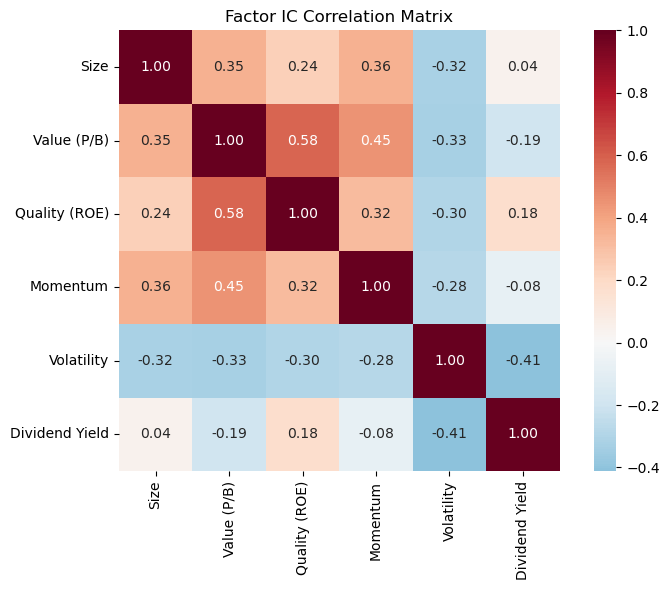

In [13]:
# Compute IC time series for each factor (pooled across industries)
ic_series_dict = {}
for fac, neutral_fac in zip(FACTOR_COLUMNS, neutral_factors):
    ic_df = compute_monthly_ic(df_resid, neutral_fac, RETURN_COL_TESTING)
    ic_series_dict[FACTOR_NAMES[fac]] = ic_df.set_index('ym')['ic']

ic_corr = compute_ic_correlation(ic_series_dict)
print('=== IC Correlation Matrix ===')
print(ic_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ic_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax)
ax.set_title('Factor IC Correlation Matrix')
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/figures/ic_correlation_matrix.pdf')
plt.show()

## 11. Rolling IC Stability

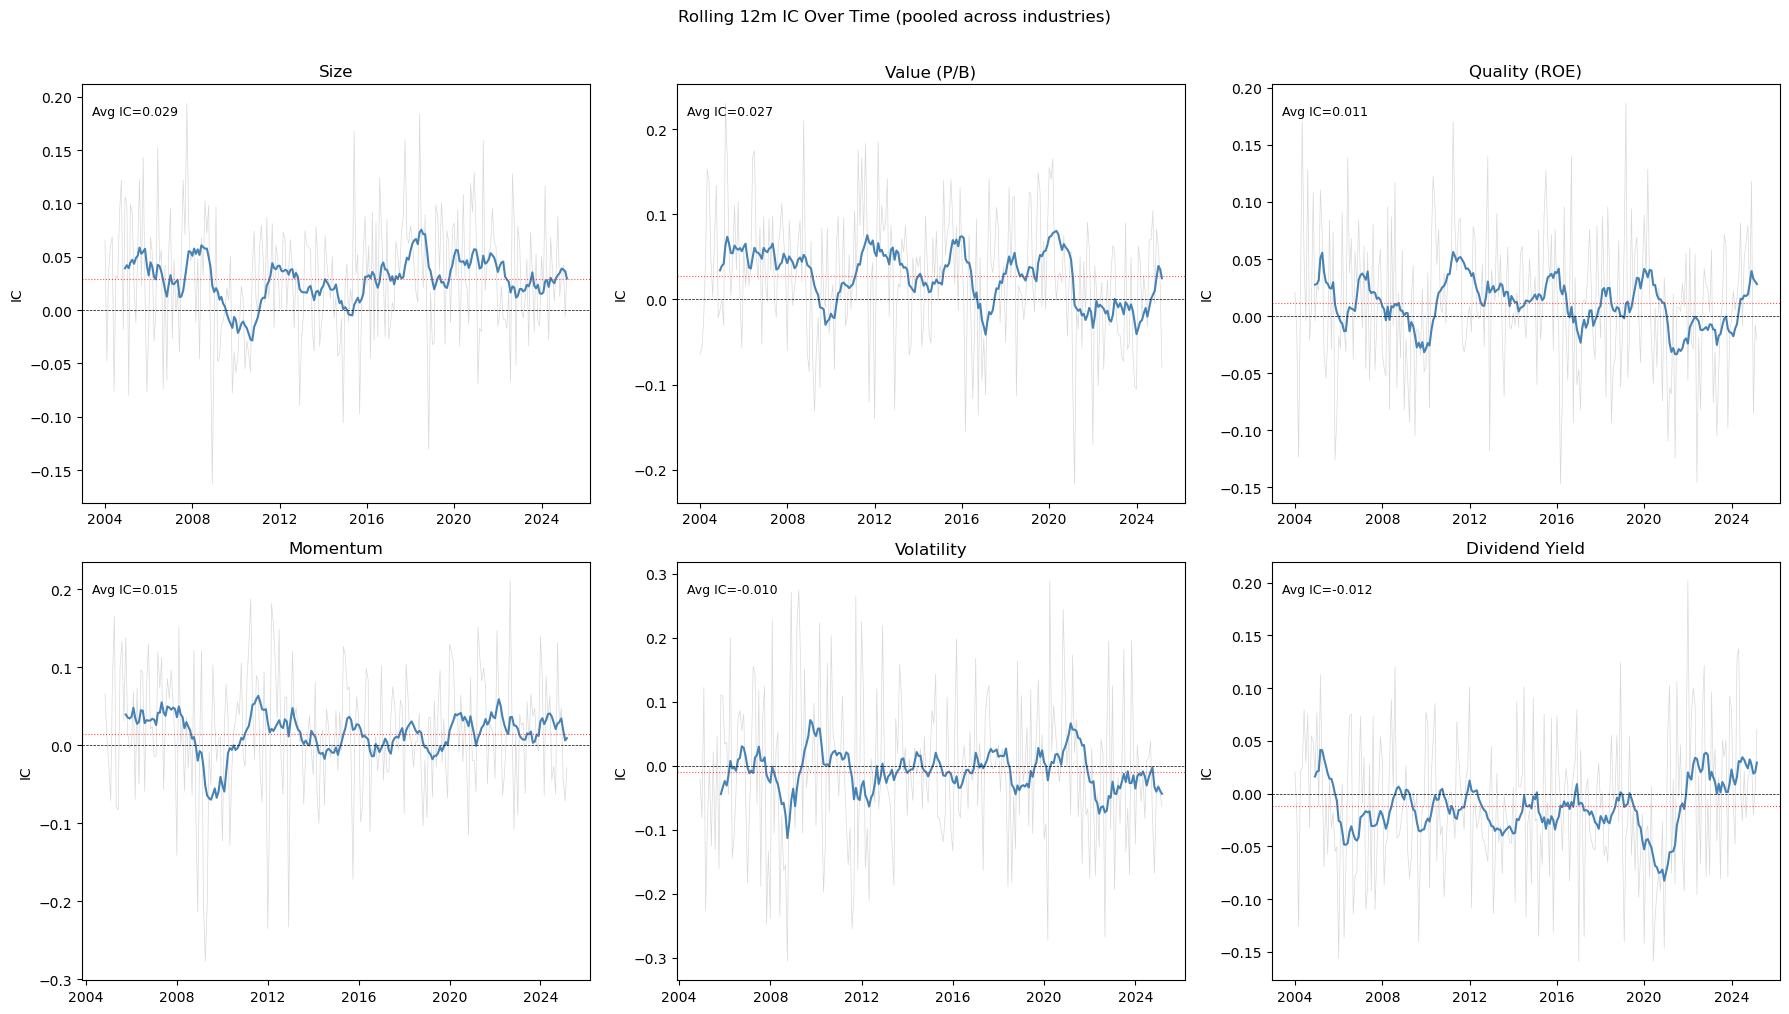

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (fac_name, ic_s) in zip(axes.flat, ic_series_dict.items()):
    rolling_ic = ic_s.rolling(12).mean()
    ax.plot(ic_s.index, ic_s.values, alpha=0.3, linewidth=0.5, color='gray')
    ax.plot(rolling_ic.index, rolling_ic.values, linewidth=1.5, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f'{fac_name}')
    ax.set_ylabel('IC')
    avg = ic_s.mean()
    ax.axhline(avg, color='red', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.text(0.02, 0.95, f'Avg IC={avg:.3f}', transform=ax.transAxes,
            verticalalignment='top', fontsize=9)

fig.suptitle('Rolling 12m IC Over Time (pooled across industries)', y=1.01)
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/figures/rolling_ic_timeseries.pdf')
plt.show()

## 12. Save Results

In [15]:
raw_ic_table.to_csv(f'{OUTPUT_DIR}/csv/ic_raw_returns.csv')
resid_ic_table.to_csv(f'{OUTPUT_DIR}/csv/ic_residual_returns.csv')
comparison.to_csv(f'{OUTPUT_DIR}/csv/ic_raw_vs_residual.csv')
ic_corr.to_csv(f'{OUTPUT_DIR}/csv/ic_correlation_matrix.csv')

# Save the processed data with betas and residual returns for subsequent notebooks
df_resid.to_csv(f'{OUTPUT_DIR}/csv/df_with_beta_resid.csv', index=False)
print(f'Saved processed data with betas/residuals: {df_resid.shape}')
print('Experiment 1 complete.')

Saved processed data with betas/residuals: (98616, 59)
Experiment 1 complete.


## 13. Summary

Key findings from Experiment 1:

1. **Size (log market cap)** is the most consistent predictor across industries -- best factor in 7 of 11 industries for raw returns, with the highest average |IC| across industries. Positive IC: smaller stocks within each industry outperform.
2. **Value (P/B)** has positive IC in all 11 industries, meaning higher P/B stocks outperform. This contradicts the classic "value premium" and suggests a growth premium in EM markets. The direction is determined empirically (data-driven) in the portfolio construction.
3. **Dividend Yield** has negative IC in 9 of 11 industries -- low dividend yield stocks outperform, consistent with the growth premium observation.
4. **Momentum (11m)** shows positive IC in most industries but is generally weaker than Size and Value.
5. **Volatility** has negative IC across most industries (low vol is better) but weak signal strength (low t-stats).
6. **Quality (ROE)** is moderately significant in select industries (UTILS, BMATR) but weak overall.
7. **Raw vs residual returns**: Average |IC| is virtually identical (0.0215 vs 0.0215). Raw return prediction produces better portfolio performance (Sharpe 0.586 vs 0.555). Raw is used as the primary prediction target.

These results inform the dynamic factor selection strategy in Experiment 2.